<a href="https://colab.research.google.com/github/Bica-plus-equals/Titanic-Logistic-Regression/blob/main/LogisticRegression_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Titanic Survival Predictions

Predict passenger survival using *logistic regression*. The notebook focuses on *feature engineering and validation* best practices, leading to an analysis on **the accuracy potential of logistic models on real-life datasets**.

### 1. Loading Data


In [46]:
#Imports
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.stats import norm
import warnings

import seaborn as sns

sns.set_theme(style='whitegrid')

In [34]:
# Kaggle downloads
path = kagglehub.dataset_download("shuofxz/titanic-machine-learning-from-disaster")
content = os.listdir(path)
print(content)

Using Colab cache for faster access to the 'titanic-machine-learning-from-disaster' dataset.
['train.csv', 'test.csv']


In [35]:
#Load train/test data
train_data = pd.read_csv(os.path.join(path, 'train.csv'))
test_data = pd.read_csv(os.path.join(path, 'test.csv'))


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


### 2. Data Investigation

In [4]:
#Check nb of features and samples
print(train_data.shape)

#Get index dtype and columns, non-NA values and memory usage
print('*'*30)
train_data.info()

#Count null-values
print('*'*30)
print('Number of null samples per feature')
train_data.isnull().sum() #it summs all the 'True' instances


(891, 12)
******************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
******************************
Number of null samples per feature


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


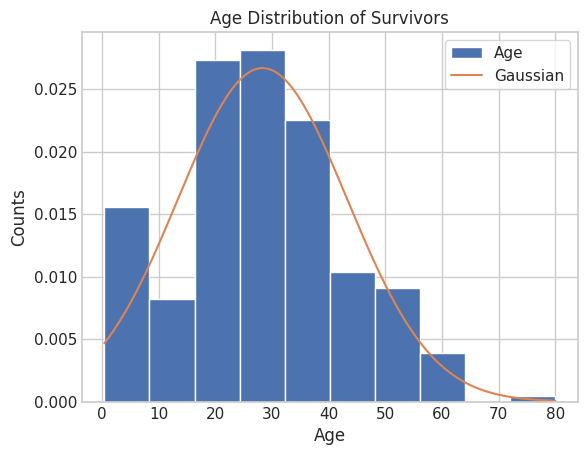

In [48]:
#Plot some distributions of survivors to identify patterns

survived_list = train_data[train_data['Survived'] == 1]

ages = survived_list['Age']

ages.plot(kind='hist',
          density=True)

#Fit a Gaussian for comparison
mu = ages.mean()
sigma = ages.std()
x = np.linspace(ages.min(), ages.max(), 200)
y = norm.pdf(x, mu, sigma)

plt.plot(x,y,label='Gaussian')
plt.title('Age Distribution of Survivors')
plt.xlabel('Age')
plt.legend()
plt.ylabel('Counts')
plt.tick_params(direction='in')
plt.show()

In [6]:
#See how many labels of each class there are
train_data['Survived'].value_counts()

,count
Survived,
0,549
1,342


### 3. Cleaning Data

Remove Cabin column - 712 remaining data points


In [7]:
train_data = train_data.drop(['Cabin'], axis=1)
test_data = test_data.drop(['Cabin'], axis=1)

#Drop all non-full entries
train_data = train_data.dropna(axis=0) #712 remaining data points
test_data = test_data.dropna(axis=0) # 331 remaining data points

# print(train_data.info())
# print(test_data.info())

### 4. Feature Engineering

1. Name : the 'name' data is often a long, unique-valued string. We extract the useful signals such as the titles: Mr, Miss, Mrs, Master. Unusual titles are mapped onto these values based on gender.

2. Encode gender and keep only one variable
3. Create 'Family_members' variable by combining 'SibSp' (number of siblings/spouses) and 'Parch' (number of parents/children) to get a stronger signal of relatedness.
4. Extract signal from 'Ticket' data showing the number of times the same ticket was used (ie groups travelling together).
5. Drop passenger id (useless data)
6. Encode 'Embarked' data and show final features

In [8]:
def feature_eng(df):
  # Extract titles and drop name data
  df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
  df = df.drop(['Name'], axis=1)

  # Map titles onto a few groups: common titles + rare
  common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
  df['Title'] = df['Title'].apply(lambda x: 'Rare' if x not in common_titles else x)
  df = pd.get_dummies(df, columns=['Title'], drop_first=False)

  # Gender
  df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

  # SibSp and Parch
  df['Family_members'] = df['SibSp'] + df['Parch']
  df = df.drop(['SibSp', 'Parch'], axis=1)

  # Ticket
  ticket_counts = df['Ticket'].value_counts()
  df['TicketGroupSize'] = df['Ticket'].map(ticket_counts)
  df.drop(['Ticket'], axis=1, inplace=True)

  # Embarked
  if 'Embarked' in df.columns and df['Embarked'].isnull().any():
      df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
  df = pd.get_dummies(df, columns=['Embarked'], drop_first=False)

  # ID
  if 'PassengerId' in df.columns:
    df.drop(['PassengerId'], axis=1, inplace=True)

  return df

# Apply feature engineering to train data
train_data = feature_eng(train_data)
print("Train data columns after feature engineering:", train_data.columns.tolist())

# Make a copy of test_data to avoid modifying the original test_data DataFrame if it's used elsewhere
test_data_processed = feature_eng(test_data.copy())
print("Test data columns after feature engineering:", test_data_processed.columns.tolist())

Train data columns after feature engineering: ['Survived', 'Pclass', 'Age', 'Fare', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Sex_male', 'Family_members', 'TicketGroupSize', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
Test data columns after feature engineering: ['Pclass', 'Age', 'Fare', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Sex_male', 'Family_members', 'TicketGroupSize', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


###5. Model Training and Fine-Tuning (Logistic Regression)

Baseline

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = train_data

y = df['Survived']
X = df.drop(['Survived'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

predictions = logistic_model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)
print("Accuracy:", accuracy)

#or use: logistic_model.score(X_val, y_val)

Accuracy: 0.8111888111888111


####5.1. Model Fine-tuning: significant

#####Experiment#1: Solver settings

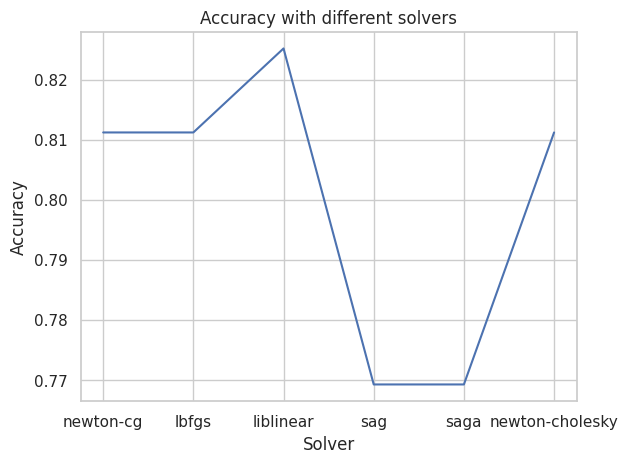

In [50]:
# from sklearn.exceptions import ConvergenceWarning

# warnings.filterwarnings('ignore', category=ConvergenceWarning)

solvers = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga', 'newton-cholesky']

accuracy_res = []

for solver in solvers:
  logistic_model = LogisticRegression(max_iter=5000, solver=solver)
  logistic_model.fit(X_train, y_train)
  predictions = logistic_model.predict(X_val)
  accuracy = accuracy_score(y_val, predictions)
  accuracy_res.append(accuracy)

plt.plot(solvers, accuracy_res)
plt.title('Accuracy with different solvers')
plt.xlabel('Solver')
plt.ylabel('Accuracy')
plt.show()

liblinear is better +1%

#####Experiment#2: Nb of iterations

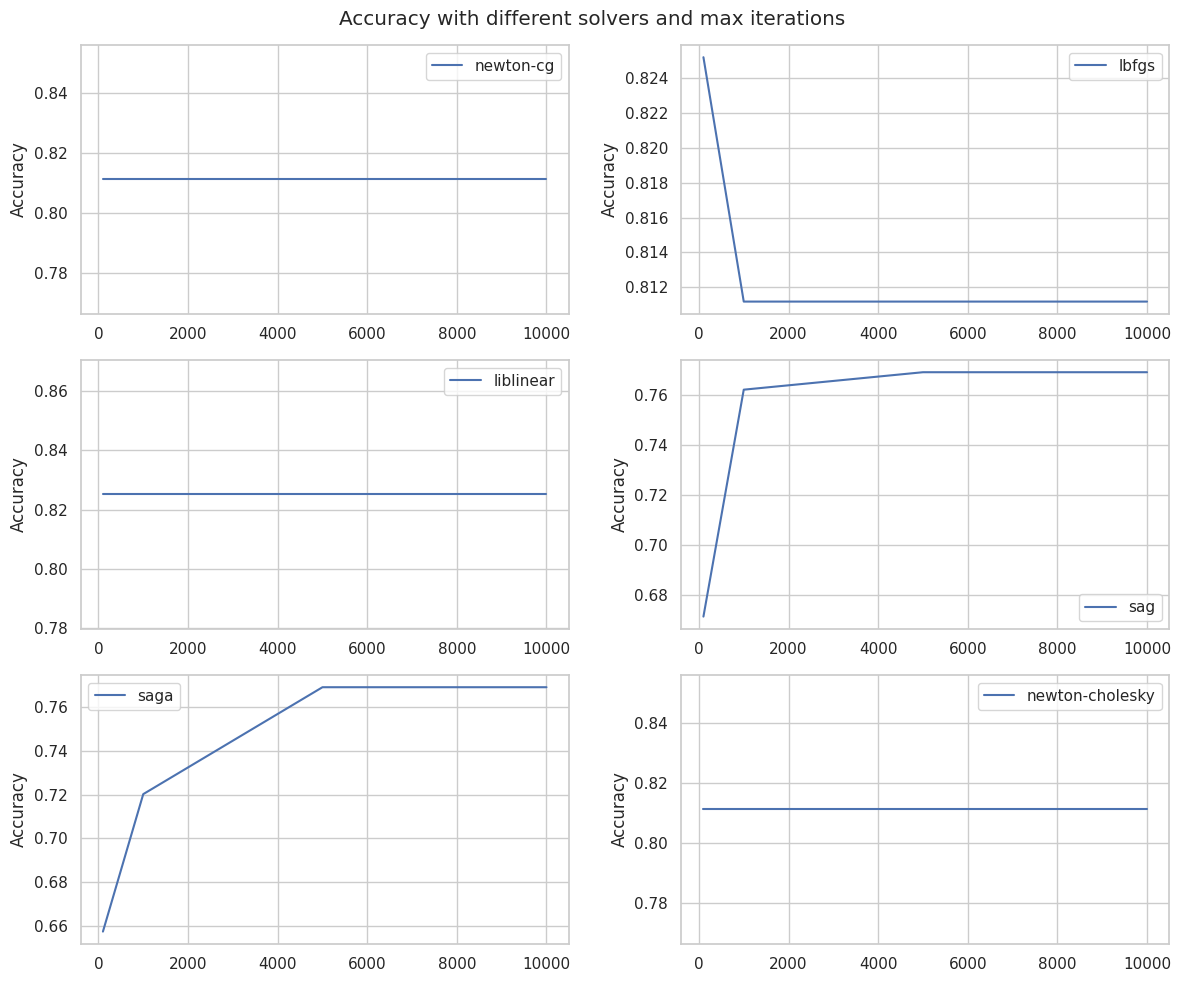

In [51]:
from sklearn.exceptions import ConvergenceWarning
import warnings
max_iter_vals = [100, 1000, 5000,10000]

# accuracy_res = []
#solver = 'lbfgs'

warnings.filterwarnings('ignore', category=ConvergenceWarning)

solvers = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga', 'newton-cholesky']

#Create 3x2 subplots
fig, axes = plt.subplots(3,2, figsize=(12,10))
axes = axes.flatten()


for i, solver in enumerate(solvers):

  accuracy_res = []

  for max_iter in max_iter_vals:

    logistic_model = LogisticRegression(max_iter=max_iter,solver=solver)
    logistic_model.fit(X_train, y_train)
    predictions = logistic_model.predict(X_val)
    accuracy = accuracy_score(y_val, predictions)
    accuracy_res.append(accuracy)

  axes[i].plot(max_iter_vals, accuracy_res,label=solver)
  axes[i].legend()
  #axes[i].set_xlabel('max nb. of iterations')
  axes[i].set_ylabel('Accuracy')

fig.suptitle('Accuracy with different solvers and max iterations')
plt.tight_layout()
plt.show()


#####Experiment #3: Regulatization parameter C

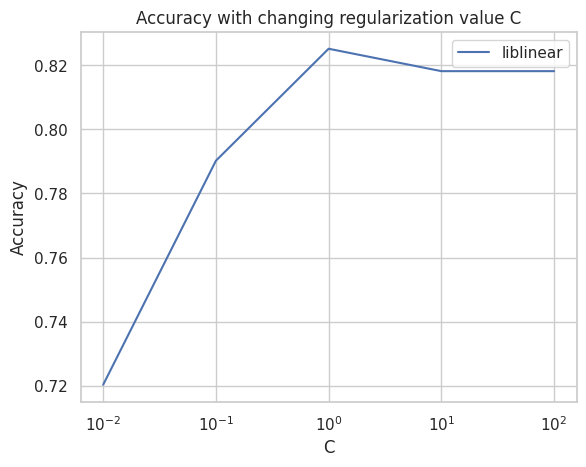

In [52]:
C_vals = [0.01, 0.1, 1, 10, 100,100]

accuracy_res = []

for C in C_vals:
  logistic_model = LogisticRegression(max_iter=1000, C = C, solver='liblinear')

  logistic_model.fit(X_train, y_train)

  predictions = logistic_model.predict(X_val)

  accuracy = accuracy_score(y_val, predictions)

  accuracy_res.append(accuracy)

plt.title('Accuracy with changing regularization value C')
plt.plot(C_vals, accuracy_res, label='liblinear')
plt.legend()
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.show()

#####Experiment#4 : Elastic-net L1_ratio

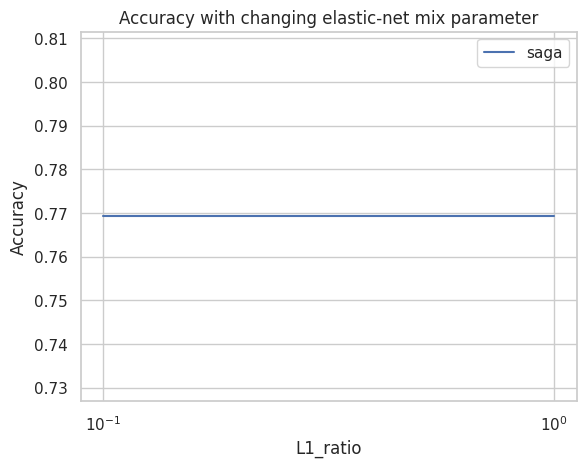

In [53]:
# from sklearn.exceptions import ConvergenceWarning

# warnings.filterwarnings('ignore', category=ConvergenceWarning)

l1_vals = [0.1, 0.2, 0.5, 1]

accuracy_res = []

for l1 in l1_vals:

  logistic_model = LogisticRegression(max_iter=5000, l1_ratio=l1, penalty='elasticnet',solver='saga')

  logistic_model.fit(X_train, y_train)

  predictions = logistic_model.predict(X_val)

  accuracy = accuracy_score(y_val, predictions)

  accuracy_res.append(accuracy)

plt.plot(l1_vals, accuracy_res, label='saga')
plt.title('Accuracy with changing elastic-net mix parameter')
plt.xscale('log')
plt.legend()
plt.xlabel('L1_ratio')
plt.ylabel('Accuracy')
plt.show()

####5.2. Feature improvements: no effect

#####Fewer Male signifiers: Exact same result

In [14]:
#Reducing male features
newdf = df.copy()

newdf = newdf.drop(['Title_Master' ,'Title_Miss', 'Title_Mr', 'Title_Mrs',
 'Title_Rare'], axis=1)

In [15]:
y = newdf['Survived']
X = newdf.drop(['Survived'], axis=1)

logistic_model1 = LogisticRegression(max_iter=2000)

X_train, X_val, y_train, y_val = train_test_split(
  X, y,  test_size=0.2, random_state=42)

logistic_model1.fit(X_train, y_train)

print(logistic_model1.score(X_val, y_val))

0.8111888111888111


**Note:** Exact same results, regardless of reducing male features to only one.

#####Handling continous data: polynomials, normalization and binning made it worse or did nothing

Using Age-squared to improve linear signal: no improvements

In [16]:
newdf = df.copy()

newdf['Age2'] = newdf['Age'] ** 2
newdf = newdf.drop(['Age'], axis=1)

X = newdf.drop(['Survived'], axis=1)
y = newdf['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size = 0.2, random_state=42)

logistic_model2 = LogisticRegression(max_iter=1000)

logistic_model2.fit(X_train, y_train)

print(logistic_model2.score(X_val, y_val))

0.8111888111888111


Normalization: no improvement

In [17]:
from sklearn.preprocessing import StandardScaler

newdf = df.copy()

scaler = StandardScaler()

X = newdf.drop(['Survived'], axis=1)
y = newdf['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size = 0.2, random_state=42)

X_train[['Age','Fare']] = scaler.fit_transform(X_train[['Age','Fare']])
X_val[['Age','Fare']] = scaler.transform(X_val[['Age','Fare']])

logistic_model3 = LogisticRegression(max_iter=1000)

logistic_model3.fit(X_train, y_train)

print(logistic_model3.score(X_val, y_val))

0.8111888111888111


Categorizing / Binning: nothing

In [18]:
newdf = df.copy()

newdf['AgeGroup'] = pd.cut(newdf['Age'], bins=[0,20,50,100])
newdf = pd.get_dummies(newdf, columns=['AgeGroup'])
newdf = newdf.drop(['Age'], axis=1)

In [19]:
y = newdf['Survived']
X = newdf.drop(['Survived'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

logistic_model4 = LogisticRegression(max_iter=1000)

logistic_model4.fit(X_train, y_train)

print(logistic_model4.score(X_val, y_val))

0.8181818181818182


#####Log-transform fare -  it has a skewed distribution so it might help learning since it will make it more uniform: no change

In [20]:
newdf = df.copy()

newdf['Fare_log'] = np.log1p(newdf['Fare'])
newdf = newdf.drop(['Fare'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

logistic_model5 = LogisticRegression(max_iter=1000)

logistic_model5.fit(X_train, y_train)

print(logistic_model5.score(X_val, y_val))


0.8181818181818182


again, absolutely nothing changed

#####Add 'Alone' parameter

In [21]:
newdf = df.copy()

newdf['Alone'] = (newdf['Family_members'] == 0).astype(int)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

logistic_model6 = LogisticRegression(max_iter=1000)

logistic_model6.fit(X_train, y_train)

print(logistic_model6.score(X_val, y_val))

0.8181818181818182


exactly the same

###6. Validation

In [54]:
y = df['Survived']
X = df.drop(['Survived'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

logistic_model = LogisticRegression(C=50, solver='liblinear',max_iter=2000,)

logistic_model.fit(X_train, y_train)

predictions = logistic_model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8181818181818182


Cross-validation

In [55]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(logistic_model, X, y, cv=5)

print(scores)
print(scores.mean())
print(scores.std())

[0.77622378 0.84615385 0.78873239 0.8028169  0.85915493]
0.8146163695459471
0.03243915720825738


oh wow, this is interesting. there is quite a variation! the std is like 3.2%. Data is small enough that sampling matters.So the model is not very 'stable', it will give different results based on the train/test split chosen.

Stratified K-fold

In [56]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(logistic_model, X, y, cv=cv)

print(scores)
print(scores.mean())
print(scores.std())

[0.86713287 0.83216783 0.78169014 0.77464789 0.85211268]
0.8215502807052102
0.03718394774269096


The model performance is closer to that 82% seen in the Experiment#3, but the variation is higher, at 3.7%

LOOCV (bc the dataset is small)

In [57]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

scores = cross_val_score(logistic_model, X, y, cv=loo)

#print(scores)
print(scores.mean())
print(scores.std())

0.824438202247191
0.380446912094987


Accuracy is the same, but std is even higher (which makes sence since the leave-one-out technique had more variability).

###7. Results & Discussion


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, predictions)
print(cm)

[[70 10]
 [16 47]]


70 - true negatives; 46 - true positives
10 - false positives 17 - false negatives -> model creates more false negatives (but this could be again because of skewed data/there are more negative training labels than positive)

In [27]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_val, predictions))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        80
           1       0.82      0.75      0.78        63

    accuracy                           0.82       143
   macro avg       0.82      0.81      0.81       143
weighted avg       0.82      0.82      0.82       143



- Recall: Since there are more examples of non-survivors, the model predicts more negative labels, reflected in the high recall value. Should there be more positive data, or at least an equal amount, the predictions could be improved.

- Precision: Positive predictions have slightly higher precision than negative ones, hence positive predictions can be trusted more.
- F1-score: Reflects the negative bias.
- Support: Reflects imbalanced data.


In [28]:
#ROC-AUC (using predicted probabilities, not absolute values)
#look more into this

from sklearn.metrics import roc_auc_score

probs = logistic_model.predict_proba(X_val)[:,1]

score = roc_auc_score(y_val, probs)

print('ROC-AUC:',score)

ROC-AUC: 0.844047619047619


ROC-AUC results of 0.84 are strong, but this is strongly influenced by the data imbalance. A precision-recall curve should be used for comparison.

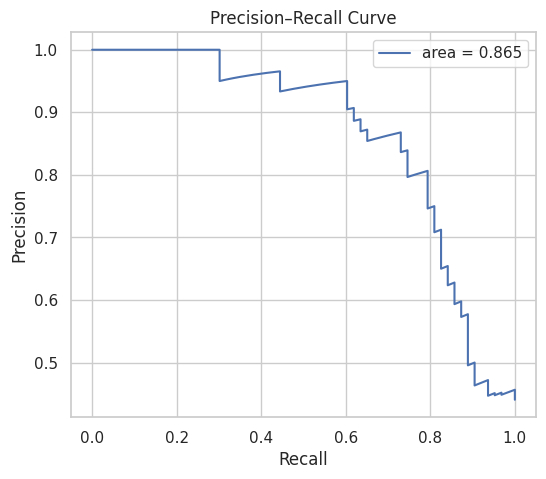

In [29]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

y_scores = logistic_model.predict_proba(X_val)[:, 1]

area = average_precision_score(y_val, y_scores)

precision, recall, thresholds = precision_recall_curve(y_val, y_scores)


plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'area = {area:.3f}')

plt.xlabel("Recall")
plt.legend()
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)

plt.show()

Since the test_data does not contain the testing labels, these predictions should be submitted to kaggle to find the final performance results.

In [30]:
#Make new predictions
predictions = logistic_model.predict(test_data_processed)

In [31]:
#Inspect model attributes
# print('Feature Names:', logistic_model.feature_names_in_)
# print('Coefficients:',logistic_model.coef_)
# print('Classes ndarray:',logistic_model.classes_)

print('Intercept :', logistic_model.intercept_)
print('Nb of features see:', logistic_model.n_features_in_)
print('Nb of iterations for all classes:', logistic_model.n_iter_)

coefs_dict = {'Feature': logistic_model.feature_names_in_,
                        'Coefficient': logistic_model.coef_[0]}
coefs_df = pd.DataFrame(coefs_dict)

print('')
print('Features from strongest negative to strongest positive')
print(coefs_df.sort_values(by='Coefficient', ascending=True))

Intercept : [4.3217735]
Nb of features see: 14
Nb of iterations for all classes: [18]

Features from strongest negative to strongest positive
            Feature  Coefficient
8          Sex_male    -3.603719
0            Pclass    -1.252230
4        Title_Miss    -0.502135
10  TicketGroupSize    -0.410548
9    Family_members    -0.148196
1               Age    -0.030312
2              Fare     0.002828
5          Title_Mr     0.167849
7        Title_Rare     0.492578
6         Title_Mrs     0.549596
12       Embarked_Q     0.968426
13       Embarked_S     1.512225
11       Embarked_C     1.841122
3      Title_Master     3.613885


- **Model convergence**: 18 iterations, which is relatively fast, indicating that the optimization process is stable.
- **Intercept:** strongly positive to maybe counter-act the effect of many negative predictors.
- **Negative coefficients -> decrease probability of survival / Positive coefficients -> increase probability of survival**
- **Strong negatives:** gender (Sex_male = -3.60), class, miss (slightly negative which does not make sense really), ticket group size (larger groups have slightly reduced survival), family_member and age (both of which are unexpectedly negative).
-**Strong positives**: master (child), embarkation location, mrs title, rare titles, mr (surprisingly), fare (very small, it would make sense to be alrger)
- **Continous variables: 'Age' & 'Fare'** have small coefficients to stabalise the absolute values. The coefficients do not reflect the contribution of these features to the survival probability, sincethe contribution to the loss function is scales by the real vale of age/fare as $x_{i}*w_{i}$. The signs of the coefficients are important here - age is negative (older people have lower survival prob), fare is positive (more expensive rates have higher survival prod).

###8. Comparison Models

Decision Tree


In [76]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

dtree_model = DecisionTreeClassifier(random_state=42, max_depth=3)

dtree_model.fit(X_train, y_train)

predictions = dtree_model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)
print('Accuracy:',accuracy)

Accuracy: 0.7972027972027972


Random Forest



In [73]:
from sklearn.ensemble import RandomForestClassifier

rforest_model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5)

rforest_model.fit(X_train, y_train)

predictions = rforest_model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)

print('Accuracy:',accuracy)



Accuracy: 0.8041958041958042
